# NB05 — Normalización por Exposición
**VíaSegura AI — Metodología IPI**

El IPI absoluto (NB02) prioriza por volumen. Este notebook calcula tasas de siniestralidad normalizadas por:
- **Denominador A:** km de red vial (OSM) — proxy de exposición vehicular
- **Denominador B:** 100,000 habitantes (DANE 2018, nivel localidad) — exposición peatonal y residencial

**Output central:** tipología de 4 categorías que identifica zonas con riesgo absoluto Y relativo alto.

⚠️ Limitación L-10: OSM no es la red oficial IDECA. Puede subestimar vías locales en zonas periféricas.
⚠️ Limitación L-11: Población DANE 2018 al nivel localidad, no UPZ. Resolución limitada.
⚠️ Limitación L-12: La grilla 111m×111m introduce ruido espacial en bordes de celda.
⚠️ Limitación L-13: Las tasas son proxies. No equivalen a la tasa PIARC (requiere TPDA).

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import osmnx as ox
import folium
from folium.plugins import MarkerCluster
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from shapely.geometry import box, Point
from pathlib import Path
import warnings
import json
warnings.filterwarnings("ignore")

# Configurar osmnx
ox.settings.log_console = False
ox.settings.use_cache = True

print(f"pandas {pd.__version__}")
print(f"geopandas {gpd.__version__}")
print(f"osmnx {ox.__version__}")

pandas 3.0.2
geopandas 1.1.3
osmnx 2.1.0


In [2]:
BASE = Path(r"C:\Users\jorge\Documents\viasegura_ai")
REPORTS = BASE / "outputs" / "reports"
MAPS = BASE / "outputs" / "maps"
DATA_PROC = BASE / "data" / "processed"

# Verificar outputs
for p in [REPORTS, MAPS]:
    assert p.exists(), f"Directorio no encontrado: {p}"
print("Rutas verificadas.")

Rutas verificadas.


In [3]:
df = pd.read_csv(REPORTS / "hotspots_enriquecidos_nb04.csv")
print(f"Universo de zonas: {len(df):,}")
print(f"Columnas disponibles: {df.shape[1]}")

# Top 200 (zona de análisis principal)
df_top = df[df["en_top200_rec"] == True].copy()
print(f"\nTop 200 zonas: {len(df_top)}")
print(f"Cobertura lat_grid: {df_top['lat_grid'].notna().sum()}/{len(df_top)}")
print(f"Cobertura lon_grid: {df_top['lon_grid'].notna().sum()}/{len(df_top)}")
print(f"\nColumnas de IPI y clasificación:")
for c in ["IPI_rec", "rank_IPI_rec", "categoria_persistencia", "localidad_modal_rec"]:
    if c in df_top.columns:
        print(f"  {c}: {df_top[c].notna().sum()} no-nulos")

Universo de zonas: 19,255
Columnas disponibles: 51

Top 200 zonas: 200
Cobertura lat_grid: 200/200
Cobertura lon_grid: 200/200

Columnas de IPI y clasificación:
  IPI_rec: 200 no-nulos
  rank_IPI_rec: 200 no-nulos
  categoria_persistencia: 200 no-nulos
  localidad_modal_rec: 200 no-nulos


## Sección 1: Red vial OSM
Descargamos el grafo vial de Bogotá (tipo 'drive', excluye peatonales) y calculamos
la longitud total de vías dentro de cada celda de la grilla.

**Denominador A:** `km_red_osm` = metros de red vial que intersectan la celda ÷ 1000

> **Nota API osmnx 2.x:** `graph_from_bbox(bbox=(left, bottom, right, top))` — orden `(oeste, sur, este, norte)` en EPSG:4326.

In [4]:
print("Descargando red vial de Bogotá desde OSM...")
print("(primera descarga ~2-3 min; usa caché en ejecuciones posteriores)")

# Bounding box de las zonas de análisis (con margen)
# osmnx 2.x: bbox=(left, bottom, right, top) = (west, south, east, north)
lat_min = df["lat_grid"].min() - 0.01
lat_max = df["lat_grid"].max() + 0.01
lon_min = df["lon_grid"].min() - 0.01
lon_max = df["lon_grid"].max() + 0.01

G = ox.graph_from_bbox(
    bbox=(lon_min, lat_min, lon_max, lat_max),  # (west, south, east, north)
    network_type="drive"
)

# Obtener edges como GeoDataFrame
edges = ox.graph_to_gdfs(G, nodes=False)
print(f"\nRed vial descargada:")
print(f"  Nodos: {len(G.nodes):,}")
print(f"  Aristas (segmentos): {len(edges):,}")
print(f"  CRS: {edges.crs}")

# Calcular longitud si no está (osmnx normalmente la incluye en metros)
if "length" not in edges.columns:
    edges = edges.to_crs("EPSG:3116")  # Colombia Bogotá projection
    edges["length"] = edges.geometry.length
    edges = edges.to_crs("EPSG:4326")
else:
    print(f"  Longitud total: {edges['length'].sum()/1000:.1f} km")

Descargando red vial de Bogotá desde OSM...
(primera descarga ~2-3 min; usa caché en ejecuciones posteriores)



Red vial descargada:
  Nodos: 69,631
  Aristas (segmentos): 174,311
  CRS: epsg:4326
  Longitud total: 14884.9 km


In [5]:
# Crear polígonos de grilla (cada celda es 0.001° × 0.001°)
HALF = 0.0005  # la mitad del lado de la celda

def make_cell_polygon(lat, lon, half=HALF):
    return box(lon - half, lat - half, lon + half, lat + half)

# GeoDataFrame del universo completo de zonas
gdf_zonas = gpd.GeoDataFrame(
    df[["lat_grid", "lon_grid"]].copy(),
    geometry=[make_cell_polygon(r.lat_grid, r.lon_grid) for _, r in df[["lat_grid", "lon_grid"]].iterrows()],
    crs="EPSG:4326"
)
gdf_zonas["idx_original"] = df.index.values

print(f"Polígonos de grilla creados: {len(gdf_zonas):,}")

# Asegurar mismo CRS
if edges.crs.to_epsg() != 4326:
    edges = edges.to_crs("EPSG:4326")

# Spatial join: qué edges caen en cada celda
print("Realizando intersección espacial (puede tardar ~1-2 min)...")
joined = gpd.sjoin(
    edges[["length", "geometry"]].reset_index(drop=True),
    gdf_zonas,
    how="inner",
    predicate="intersects"
)

# Longitud total de red por zona
longitud_por_zona = joined.groupby("idx_original")["length"].sum().reset_index()
longitud_por_zona.columns = ["idx_original", "longitud_red_m"]
longitud_por_zona["km_red_osm"] = longitud_por_zona["longitud_red_m"] / 1000

# Unir al dataframe principal
df = df.reset_index(drop=True)
df = df.merge(longitud_por_zona[["idx_original", "km_red_osm"]],
              left_index=True, right_on="idx_original", how="left")
df["km_red_osm"] = df["km_red_osm"].fillna(0)
df = df.drop(columns=["idx_original"], errors="ignore")

# Reporte
print(f"\nResultados de red vial por zona:")
print(f"  Zonas con red vial (>0 m): {(df['km_red_osm'] > 0).sum():,} / {len(df):,}")
print(f"  Zonas sin red mapeada:     {(df['km_red_osm'] == 0).sum():,}")
print(f"\n  Estadísticas km_red_osm (solo zonas con red):")
print(df[df['km_red_osm'] > 0]['km_red_osm'].describe().to_string())

# En Top 200
df_top = df[df["en_top200_rec"] == True].copy()
print(f"\n  Top 200 — zonas con red: {(df_top['km_red_osm'] > 0).sum()}/200")
print(f"  Top 200 — km_red_osm promedio: {df_top['km_red_osm'].mean():.3f} km")

Polígonos de grilla creados: 19,255
Realizando intersección espacial (puede tardar ~1-2 min)...



Resultados de red vial por zona:
  Zonas con red vial (>0 m): 18,963 / 19,255
  Zonas sin red mapeada:     292

  Estadísticas km_red_osm (solo zonas con red):
count    18963.000000
mean         1.184279
std          0.632537
min          0.033486
25%          0.767153
50%          1.101008
75%          1.489090
max         16.120302

  Top 200 — zonas con red: 200/200
  Top 200 — km_red_osm promedio: 1.485 km


## Sección 2: Población DANE 2018 (nivel localidad)

Usamos la población DANE Censo 2018 por localidad como denominador.
**Resolución:** localidad (≈20 localidades en Bogotá). 
**Mejora futura (L-11):** reemplazar por datos UPZ (112 unidades) o WorldPop (grilla 100m).

Fuente: DANE CNPV 2018, Bogotá D.C.

In [6]:
# Población DANE 2018 por localidad (CNPV 2018, tabla oficial)
# Fuente: DANE — Resultados Censo Nacional de Población y Vivienda 2018
POB_LOCALIDAD = {
    "USAQUEN":           507226,
    "CHAPINERO":         139386,
    "SANTA FE":          109570,
    "SAN CRISTOBAL":     400927,
    "USME":              442385,
    "TUNJUELITO":        199430,
    "BOSA":              777967,
    "KENNEDY":          1230539,
    "FONTIBON":          421239,
    "ENGATIVA":          887752,
    "SUBA":             1341216,
    "BARRIOS UNIDOS":    254462,
    "TEUSAQUILLO":       148373,
    "LOS MARTIRES":      100022,
    "ANTONIO NARINO":    115053,
    "PUENTE ARANDA":     258441,
    "LA CANDELARIA":      24096,
    "RAFAEL URIBE URIBE": 378284,
    "CIUDAD BOLIVAR":    733859,
    "SUMAPAZ":             6533,
}

df_pob = pd.DataFrame(list(POB_LOCALIDAD.items()), columns=["localidad_key", "poblacion_2018"])
print("Población DANE 2018 por localidad:")
print(df_pob.to_string(index=False))
print(f"\nTotal: {df_pob['poblacion_2018'].sum():,} habitantes")

Población DANE 2018 por localidad:
     localidad_key  poblacion_2018
           USAQUEN          507226
         CHAPINERO          139386
          SANTA FE          109570
     SAN CRISTOBAL          400927
              USME          442385
        TUNJUELITO          199430
              BOSA          777967
           KENNEDY         1230539
          FONTIBON          421239
          ENGATIVA          887752
              SUBA         1341216
    BARRIOS UNIDOS          254462
       TEUSAQUILLO          148373
      LOS MARTIRES          100022
    ANTONIO NARINO          115053
     PUENTE ARANDA          258441
     LA CANDELARIA           24096
RAFAEL URIBE URIBE          378284
    CIUDAD BOLIVAR          733859
           SUMAPAZ            6533

Total: 8,476,760 habitantes


In [7]:
# Normalizar nombre de localidad para el join
def normalizar_localidad(s):
    if pd.isna(s): return ""
    return (s.upper()
             .replace("Á","A").replace("É","E").replace("Í","I")
             .replace("Ó","O").replace("Ú","U").replace("Ñ","N")
             .strip())

df["localidad_key"] = df["localidad_modal_rec"].apply(normalizar_localidad)

# Join con tabla de población
df = df.merge(df_pob, on="localidad_key", how="left")

# Área de cada localidad en km² (para calcular densidad si se requiere)
AREA_LOCALIDAD_KM2 = {
    "USAQUEN": 65.31, "CHAPINERO": 38.15, "SANTA FE": 45.17,
    "SAN CRISTOBAL": 49.09, "USME": 215.06, "TUNJUELITO": 9.95,
    "BOSA": 24.97, "KENNEDY": 38.98, "FONTIBON": 33.87,
    "ENGATIVA": 35.98, "SUBA": 100.56, "BARRIOS UNIDOS": 11.98,
    "TEUSAQUILLO": 14.10, "LOS MARTIRES": 6.54, "ANTONIO NARINO": 4.88,
    "PUENTE ARANDA": 17.25, "LA CANDELARIA": 1.83, "RAFAEL URIBE URIBE": 13.59,
    "CIUDAD BOLIVAR": 128.96, "SUMAPAZ": 780.66,
}
df["area_localidad_km2"] = df["localidad_key"].map(AREA_LOCALIDAD_KM2)
df["densidad_hab_km2"] = df["poblacion_2018"] / df["area_localidad_km2"]

# Reporte
df_top = df[df["en_top200_rec"] == True].copy()
print(f"Cobertura de población en universo: {df['poblacion_2018'].notna().sum():,}/{len(df):,}")
print(f"Cobertura en Top 200: {df_top['poblacion_2018'].notna().sum()}/200")

missing = df_top[df_top['poblacion_2018'].isna()]['localidad_modal_rec'].unique()
if len(missing): print(f"Localidades sin match: {missing}")

Cobertura de población en universo: 13,315/19,255
Cobertura en Top 200: 199/200
Localidades sin match: <StringArray>
['CANDELARIA']
Length: 1, dtype: str


## Sección 3: Cálculo de tasas de siniestralidad

**Tasa A (tasa_red):** siniestros recientes / km de red vial OSM
  → Captura riesgo relativo por infraestructura vial. Comparable con HIN (NACTO/Vision Zero).

**Tasa B (tasa_pob_100k):** siniestros recientes / 100,000 habitantes DANE 2018
  → Captura riesgo relativo para residentes. Compatible con métricas OMS/ANSV.

**Numerador:** `cantidad_siniestros_rec` (accidentes en el periodo reciente 2020–2021 por zona, disponible para 13,417 zonas activas)

> Cobertura: `cantidad_siniestros_rec` cubre todas las zonas con al menos un siniestro en 2020–2021 (13,417/19,255), lo que permite calcular tasas para el universo completo y detectar "Hotspot relativos ocultos" fuera del Top 200.

In [8]:
EPSILON_KM = 0.05   # mínimo 50m de red para evitar divisiones por 0 infladas

# Tasa por km de red vial
df["km_red_safe"] = df["km_red_osm"].clip(lower=EPSILON_KM)
df["tasa_red"] = df["cantidad_siniestros_rec"] / df["km_red_safe"]

# Tasa por 100,000 habitantes
df["tasa_pob_100k"] = (df["cantidad_siniestros_rec"] / df["poblacion_2018"]) * 100_000

# Para zonas sin datos de población, dejar NaN (no imputar)
df.loc[df["poblacion_2018"].isna(), "tasa_pob_100k"] = np.nan

df_top = df[df["en_top200_rec"] == True].copy()

print("Tasas calculadas en el universo completo:")
print(f"  tasa_red:      {df['tasa_red'].notna().sum():,} válidas (universo: {len(df):,})")
print(f"  tasa_pob_100k: {df['tasa_pob_100k'].notna().sum():,} válidas\n")

print("Distribución tasa_red (siniestros/km) — Top 200:")
print(df_top['tasa_red'].describe().round(2).to_string())
print(f"\nDistribución tasa_pob_100k — Top 200:")
print(df_top['tasa_pob_100k'].describe().round(2).to_string())

Tasas calculadas en el universo completo:
  tasa_red:      13,417 válidas (universo: 19,255)
  tasa_pob_100k: 13,315 válidas

Distribución tasa_red (siniestros/km) — Top 200:
count    200.00
mean      18.37
std       20.69
min        1.26
25%        7.87
50%       13.28
75%       20.41
max      224.53

Distribución tasa_pob_100k — Top 200:
count    199.00
mean       6.15
std        7.55
min        0.37
25%        1.54
50%        3.44
75%        7.01
max       45.99


## Sección 4: Normalización y rankings

Mismo método que el IPI original: percentil de rango × 100.
Permite comparar directamente con el IPI existente.

- `rank_vol`: ranking actual por IPI_rec (ya existe en el DataFrame)
- `rank_tasa_red`: ranking por tasa de siniestros por km de red (sobre las 13,417 zonas con siniestros)
- `rank_tasa_pob`: ranking por tasa por 100k habitantes

> Las tasas se calculan sobre todas las zonas con `cantidad_siniestros_rec > 0`, lo que permite identificar "Hotspot relativos ocultos" — zonas con alta tasa por km que no están en el Top 200 volumétrico.

In [9]:
# Ranking universo completo (mayor tasa = rank más alto = mayor prioridad)
def pct_rank_desc(series):
    """Percentil descendente: mayor valor → rank 1. Retorna como entero."""
    return series.rank(ascending=False, method="min", na_option="bottom").astype(int)

df["rank_vol"]      = df["IPI_rec"].rank(ascending=False, method="min", na_option="bottom").astype(int)
df["rank_tasa_red"] = pct_rank_desc(df["tasa_red"])
df["rank_tasa_pob"] = pct_rank_desc(df["tasa_pob_100k"])

# Score normalizado (0–100) para cada métrica
def score_pct(series, ascending=False):
    return series.rank(pct=True, method="average", ascending=ascending, na_option="bottom") * 100

df["score_tasa_red"] = score_pct(df["tasa_red"])
df["score_tasa_pob"] = score_pct(df["tasa_pob_100k"])

df_top = df[df["en_top200_rec"] == True].copy()

print("Rankings calculados (universo completo):")
print(f"  rank_vol      — min: {df['rank_vol'].min()}, max: {df['rank_vol'].max()}")
print(f"  rank_tasa_red — min: {df['rank_tasa_red'].min()}, max: {df['rank_tasa_red'].max()}")
print(f"  rank_tasa_pob — min: {df['rank_tasa_pob'].min()}, max: {df['rank_tasa_pob'].max()}")

print(f"\nTop 200 — posición en ranking tasa_red:")
print(f"  Median rank_tasa_red: {df_top['rank_tasa_red'].median():.0f}")
print(f"  Zonas Top 200 que están también en Top 200 por tasa_red: "
      f"{(df_top['rank_tasa_red'] <= 200).sum()}")

Rankings calculados (universo completo):
  rank_vol      — min: 1, max: 13418
  rank_tasa_red — min: 1, max: 13418
  rank_tasa_pob — min: 1, max: 13316

Top 200 — posición en ranking tasa_red:
  Median rank_tasa_red: 1157
  Zonas Top 200 que están también en Top 200 por tasa_red: 20


## Sección 5: Tipología de concordancia NB05

Las zonas del Top 200 se clasifican según su posición en los rankings volumétrico y de tasa:

| Tipología | Criterio | Interpretación |
|---|---|---|
| **Hotspot absoluto + relativo** | Top 200 IPI_vol Y Top 200 tasa_red | Problema estructural — auditoría urgente |
| **Hotspot por volumen** | Top 200 IPI_vol, rank_tasa_red > 200 | Alto tráfico explica la concentración |
| **Hotspot relativo oculto** | rank_vol > 200, Top 200 tasa_red | Sub-representado en ranking absoluto |
| **Alta tasa poblacional** | Top 200 tasa_pob, rank_vol > 200 | Equidad vial — zonas residenciales en riesgo |

In [10]:
TOP_N = 200

# Flags
df["en_top_vol"]      = df["rank_vol"] <= TOP_N
df["en_top_tasa_red"] = df["rank_tasa_red"] <= TOP_N
df["en_top_tasa_pob"] = df["rank_tasa_pob"] <= TOP_N

# Tipología para el Top 200 original
def asignar_tipologia(row):
    if row["en_top_vol"] and row["en_top_tasa_red"]:
        return "Hotspot absoluto + relativo"
    elif row["en_top_vol"] and not row["en_top_tasa_red"]:
        return "Hotspot por volumen"
    elif not row["en_top_vol"] and row["en_top_tasa_red"]:
        return "Hotspot relativo oculto"
    elif not row["en_top_vol"] and row["en_top_tasa_pob"]:
        return "Alta tasa poblacional"
    else:
        return "Sin tipología NB05"

df["tipologia_nb05"] = df.apply(asignar_tipologia, axis=1)

# Conteos
conteos = df["tipologia_nb05"].value_counts()
print("Distribución de tipología NB05 (universo completo):")
print(conteos.to_string())

df_top = df[df["en_top200_rec"] == True].copy()
print(f"\nTop 200 original — tipología NB05:")
print(df_top["tipologia_nb05"].value_counts().to_string())

# Concordancia clave
n_abs_rel = (df_top["tipologia_nb05"] == "Hotspot absoluto + relativo").sum()
n_vol_only = (df_top["tipologia_nb05"] == "Hotspot por volumen").sum()
print(f"\nConcordancia IPI_vol ↔ tasa_red en Top 200:")
print(f"  Zonas en AMBOS rankings (prioridad máxima): {n_abs_rel} ({n_abs_rel/200*100:.1f}%)")
print(f"  Zonas solo por volumen (posible efecto exposición): {n_vol_only} ({n_vol_only/200*100:.1f}%)")

Distribución de tipología NB05 (universo completo):


tipologia_nb05
Sin tipología NB05             18737
Hotspot relativo oculto          180
Hotspot por volumen              180
Alta tasa poblacional            138
Hotspot absoluto + relativo       20



Top 200 original — tipología NB05:
tipologia_nb05
Hotspot por volumen            180
Hotspot absoluto + relativo     20

Concordancia IPI_vol ↔ tasa_red en Top 200:
  Zonas en AMBOS rankings (prioridad máxima): 20 (10.0%)
  Zonas solo por volumen (posible efecto exposición): 180 (90.0%)


In [11]:
print("="*70)
print("RESUMEN ANALÍTICO NB05 — TIPOLOGÍA DE CONCORDANCIA")
print("="*70)
for tip in ["Hotspot absoluto + relativo", "Hotspot por volumen",
            "Hotspot relativo oculto", "Alta tasa poblacional"]:
    sub = df[df["tipologia_nb05"] == tip]
    if len(sub) == 0:
        continue
    print(f"\n{tip.upper()} (n={len(sub)})")
    print(f"  IPI_rec promedio         : {sub['IPI_rec'].mean():.2f}")
    print(f"  tasa_red promedio        : {sub['tasa_red'].mean():.2f} sin/km")
    print(f"  km_red_osm promedio      : {sub['km_red_osm'].mean():.3f} km")
    print(f"  siniestros_rec promedio  : {sub['cantidad_siniestros_rec'].mean():.1f}")
    if "categoria_persistencia" in sub.columns:
        print(f"  Persistentes             : {(sub['categoria_persistencia']=='Persistente').sum()}")
        print(f"  Emergentes               : {(sub['categoria_persistencia']=='Emergente').sum()}")
print("="*70)

RESUMEN ANALÍTICO NB05 — TIPOLOGÍA DE CONCORDANCIA

HOTSPOT ABSOLUTO + RELATIVO (n=20)
  IPI_rec promedio         : 92.08
  tasa_red promedio        : 59.91 sin/km
  km_red_osm promedio      : 1.048 km
  siniestros_rec promedio  : 54.9
  Persistentes             : 9
  Emergentes               : 11

HOTSPOT POR VOLUMEN (n=180)
  IPI_rec promedio         : 92.01
  tasa_red promedio        : 13.75 sin/km
  km_red_osm promedio      : 1.534 km
  siniestros_rec promedio  : 19.0
  Persistentes             : 26
  Emergentes               : 154

HOTSPOT RELATIVO OCULTO (n=180)
  IPI_rec promedio         : 67.31
  tasa_red promedio        : 53.90 sin/km
  km_red_osm promedio      : 0.586 km
  siniestros_rec promedio  : 28.7
  Persistentes             : 0
  Emergentes               : 0

ALTA TASA POBLACIONAL (n=138)
  IPI_rec promedio         : 78.51
  tasa_red promedio        : 18.78 sin/km
  km_red_osm promedio      : 1.535 km
  siniestros_rec promedio  : 25.2
  Persistentes             : 0
  E

## Sección 6: Impacto de la normalización — zonas que suben y bajan

Diferencia de ranking: `delta_rank = rank_vol - rank_tasa_red`
- **delta_rank >> 0**: la zona sube en el ranking normalizado (más peligrosa por km de lo que parecía)
- **delta_rank << 0**: la zona baja en el ranking normalizado (el volumen explicaba su posición)

In [12]:
df["delta_rank"] = df["rank_vol"] - df["rank_tasa_red"]

# Top 20 que más suben (zonas con alta tasa/km pero rank_vol bajo — fuera del Top 200)
suben = (df[df["rank_tasa_red"] <= 200]
         .sort_values("delta_rank", ascending=False)
         .head(20)
         [["lat_grid","lon_grid","rank_vol","rank_tasa_red","delta_rank",
           "tasa_red","km_red_osm","cantidad_siniestros_rec","localidad_modal_rec","tipologia_nb05"]])

# Top 20 que más bajan (del Top 200 original, los más desplazados)
bajan = (df[df["en_top200_rec"] == True]
         .sort_values("delta_rank", ascending=True)
         .head(20)
         [["lat_grid","lon_grid","rank_vol","rank_tasa_red","delta_rank",
           "tasa_red","km_red_osm","cantidad_siniestros_rec","localidad_modal_rec","tipologia_nb05"]])

print("TOP 20 ZONAS QUE MÁS SUBEN al normalizar por red vial:")
print(suben.to_string(index=False))

print("\nTOP 20 ZONAS DEL TOP 200 QUE MÁS BAJAN al normalizar:")
print(bajan.to_string(index=False))

TOP 20 ZONAS QUE MÁS SUBEN al normalizar por red vial:
 lat_grid  lon_grid  rank_vol  rank_tasa_red  delta_rank  tasa_red  km_red_osm  cantidad_siniestros_rec localidad_modal_rec          tipologia_nb05
    4.529   -74.109     10108            115        9993      40.0         0.0                      2.0                USME Hotspot relativo oculto
    4.537   -74.102     10108            115        9993      40.0         0.0                      2.0                USME Hotspot relativo oculto
    4.549   -74.104     10108            115        9993      40.0         0.0                      2.0  RAFAEL URIBE URIBE Hotspot relativo oculto
    4.603   -74.172     10108            115        9993      40.0         0.0                      2.0             KENNEDY Hotspot relativo oculto
    4.573   -74.146     10108            115        9993      40.0         0.0                      2.0      CIUDAD BOLIVAR Hotspot relativo oculto
    4.560   -74.107     10108            115        9993 

## Sección 7: Visualizaciones

- **Mapa 1:** Tipología NB05 — zonas coloreadas por categoría de concordancia
- **Mapa 2:** Calor de tasa_red — intensidad de siniestros por km de red
- **Mapa 3:** Impacto del ranking — delta entre rank_vol y rank_tasa_red

In [13]:
COLORES_TIP = {
    "Hotspot absoluto + relativo": "#D32F2F",  # rojo oscuro
    "Hotspot por volumen":          "#FF8F00",  # naranja
    "Hotspot relativo oculto":      "#1565C0",  # azul oscuro
    "Alta tasa poblacional":        "#388E3C",  # verde
    "Sin tipología NB05":           "#BDBDBD",  # gris
}

m1 = folium.Map(location=[4.65, -74.08], zoom_start=11, tiles="CartoDB positron")

# Agregar zonas del Top 200 y los Hotspot relativos ocultos
mask = df["en_top200_rec"] | (df["tipologia_nb05"] == "Hotspot relativo oculto")
for _, row in df[mask].iterrows():
    color = COLORES_TIP.get(row["tipologia_nb05"], "#BDBDBD")
    tip = row["tipologia_nb05"]
    tasa_red_val = row.get("tasa_red", None)
    tasa_str = f"{tasa_red_val:.2f}" if pd.notna(tasa_red_val) else "N/A"
    popup = (f"Tipología: {tip}<br>"
             f"rank_vol: {row['rank_vol']}<br>"
             f"rank_tasa_red: {row['rank_tasa_red']}<br>"
             f"tasa_red: {tasa_str} sin/km<br>"
             f"km_red: {row.get('km_red_osm', 0):.3f} km<br>"
             f"Localidad: {row.get('localidad_modal_rec','N/A')}")
    folium.Rectangle(
        bounds=[[row["lat_grid"]-0.0005, row["lon_grid"]-0.0005],
                [row["lat_grid"]+0.0005, row["lon_grid"]+0.0005]],
        color=color, fill=True, fill_opacity=0.7, weight=1,
        popup=folium.Popup(popup, max_width=280)
    ).add_to(m1)

# Leyenda
legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;background:white;
     padding:10px;border-radius:5px;font-size:12px;border:1px solid #ccc;">
<b>Tipología NB05</b><br>
<span style="color:#D32F2F;">&#9632;</span> Hotspot absoluto + relativo<br>
<span style="color:#FF8F00;">&#9632;</span> Hotspot por volumen<br>
<span style="color:#1565C0;">&#9632;</span> Hotspot relativo oculto<br>
<span style="color:#388E3C;">&#9632;</span> Alta tasa poblacional<br>
</div>"""
m1.get_root().html.add_child(folium.Element(legend_html))

PATH_M1 = MAPS / "tipologia_nb05.html"
m1.save(str(PATH_M1))
print(f"Mapa 1 guardado: {PATH_M1}")

Mapa 1 guardado: C:\Users\jorge\Documents\viasegura_ai\outputs\maps\tipologia_nb05.html


In [14]:
import matplotlib.cm as cm

df_map = df[df["tasa_red"].notna() & (df["rank_tasa_red"] <= 500)].copy()
vmin, vmax = df_map["tasa_red"].quantile(0.05), df_map["tasa_red"].quantile(0.95)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.YlOrRd

m2 = folium.Map(location=[4.65, -74.08], zoom_start=11, tiles="CartoDB positron")
for _, row in df_map.iterrows():
    rgba = cmap(norm(row["tasa_red"]))
    hex_color = mcolors.to_hex(rgba)
    folium.Rectangle(
        bounds=[[row["lat_grid"]-0.0005, row["lon_grid"]-0.0005],
                [row["lat_grid"]+0.0005, row["lon_grid"]+0.0005]],
        color=hex_color, fill=True, fill_opacity=0.75, weight=0.5,
        popup=f"tasa_red: {row['tasa_red']:.2f} sin/km | km_red: {row['km_red_osm']:.3f}"
    ).add_to(m2)

PATH_M2 = MAPS / "tasa_red_nb05.html"
m2.save(str(PATH_M2))
print(f"Mapa 2 guardado: {PATH_M2}")

Mapa 2 guardado: C:\Users\jorge\Documents\viasegura_ai\outputs\maps\tasa_red_nb05.html


In [15]:
df_delta = df[df["en_top200_rec"] | (df["rank_tasa_red"] <= 200)].copy()
d_min, d_max = df_delta["delta_rank"].min(), df_delta["delta_rank"].max()
norm_d = mcolors.TwoSlopeNorm(vmin=d_min, vcenter=0, vmax=d_max)
cmap_d = cm.RdBu

m3 = folium.Map(location=[4.65, -74.08], zoom_start=11, tiles="CartoDB positron")
for _, row in df_delta.iterrows():
    rgba = cmap_d(norm_d(row["delta_rank"]))
    hex_color = mcolors.to_hex(rgba)
    popup = (f"delta_rank: {row['delta_rank']:+.0f}<br>"
             f"rank_vol: {row['rank_vol']} → rank_tasa_red: {row['rank_tasa_red']}")
    folium.Rectangle(
        bounds=[[row["lat_grid"]-0.0005, row["lon_grid"]-0.0005],
                [row["lat_grid"]+0.0005, row["lon_grid"]+0.0005]],
        color=hex_color, fill=True, fill_opacity=0.75, weight=0.5,
        popup=folium.Popup(popup, max_width=250)
    ).add_to(m3)

PATH_M3 = MAPS / "delta_ranking_nb05.html"
m3.save(str(PATH_M3))
print(f"Mapa 3 guardado: {PATH_M3}")

Mapa 3 guardado: C:\Users\jorge\Documents\viasegura_ai\outputs\maps\delta_ranking_nb05.html


## Sección 8: Exports, ADR-14 y Limitaciones

### ADR-14: Índice central del proyecto

**Decisión:** El resultado central de VíaSegura AI son los rankings duales (IPI_vol + IPI_tasa_red),
no un índice único. La tipología de concordancia NB05 es el output accionable para la SDM.

**Justificación:** Un índice único combina denominadores heterogéneos y pierde interpretabilidad.
Los rankings duales permiten decisiones diferenciadas según el tipo de intervención requerida.

### Limitaciones documentadas en NB05
- **L-10:** OSM ≠ red oficial IDECA. Posible subestimación de vías locales en periferias.
- **L-11:** Población al nivel localidad, no UPZ. Mejora futura: WorldPop 100m o DANE UPZ.
- **L-12:** Grilla 111m×111m introduce ruido en bordes de celda. Solución definitiva: migrar a segmentos de red (P-R2).
- **L-13:** Tasas son proxies. No equivalen a tasa PIARC (requiere TPDA).
- **L-14:** Tasa por localidad diluye variabilidad intra-localidad.

In [16]:
# Columnas de salida de NB05
cols_out = [
    "lat_grid", "lon_grid", "localidad_modal_rec",
    # IPI original
    "IPI_rec", "rank_vol", "en_top200_rec", "categoria_persistencia",
    # Red vial
    "km_red_osm", "tasa_red", "rank_tasa_red", "score_tasa_red",
    # Población
    "poblacion_2018", "area_localidad_km2", "densidad_hab_km2",
    "tasa_pob_100k", "rank_tasa_pob", "score_tasa_pob",
    # Concordancia
    "delta_rank", "tipologia_nb05",
    # Mix vehicular (de NB04, disponible para Top 200)
    "pct_automovil", "pct_motocicleta", "pct_bus", "pct_camioneta", "pct_bicicleta",
    "pct_peaton", "pct_conductor", "pct_motociclista",
    # Siniestros (universo completo)
    "cantidad_siniestros_rec", "siniestros_con_muertos_rec",
]

# Solo incluir columnas que existan
cols_out_real = [c for c in cols_out if c in df.columns]
df_out = df[cols_out_real].copy()

PATH_OUT = REPORTS / "hotspots_normalizados_nb05.csv"
df_out.to_csv(PATH_OUT, index=False, encoding="utf-8-sig")
print(f"CSV guardado: {PATH_OUT}")
print(f"  Filas: {len(df_out):,} | Columnas: {df_out.shape[1]}")

# Resumen ejecutivo final
df_top = df_out[df_out["en_top200_rec"] == True]
print(f"\n{'='*60}")
print("RESUMEN EJECUTIVO NB05")
print(f"{'='*60}")
tip_counts = df_top["tipologia_nb05"].value_counts()
for tip, n in tip_counts.items():
    print(f"  {tip}: {n} zonas ({n/200*100:.1f}%)")
print(f"\n  Zonas con cobertura OSM completa: {(df_top['km_red_osm']>0).sum()}/200")
print(f"  tasa_red media Top 200: {df_top['tasa_red'].mean():.2f} sin/km")
print(f"  tasa_pob_100k media Top 200: {df_top['tasa_pob_100k'].mean():.1f}")

CSV guardado: C:\Users\jorge\Documents\viasegura_ai\outputs\reports\hotspots_normalizados_nb05.csv
  Filas: 19,255 | Columnas: 29

RESUMEN EJECUTIVO NB05
  Hotspot por volumen: 180 zonas (90.0%)
  Hotspot absoluto + relativo: 20 zonas (10.0%)

  Zonas con cobertura OSM completa: 200/200
  tasa_red media Top 200: 18.37 sin/km
  tasa_pob_100k media Top 200: 6.1


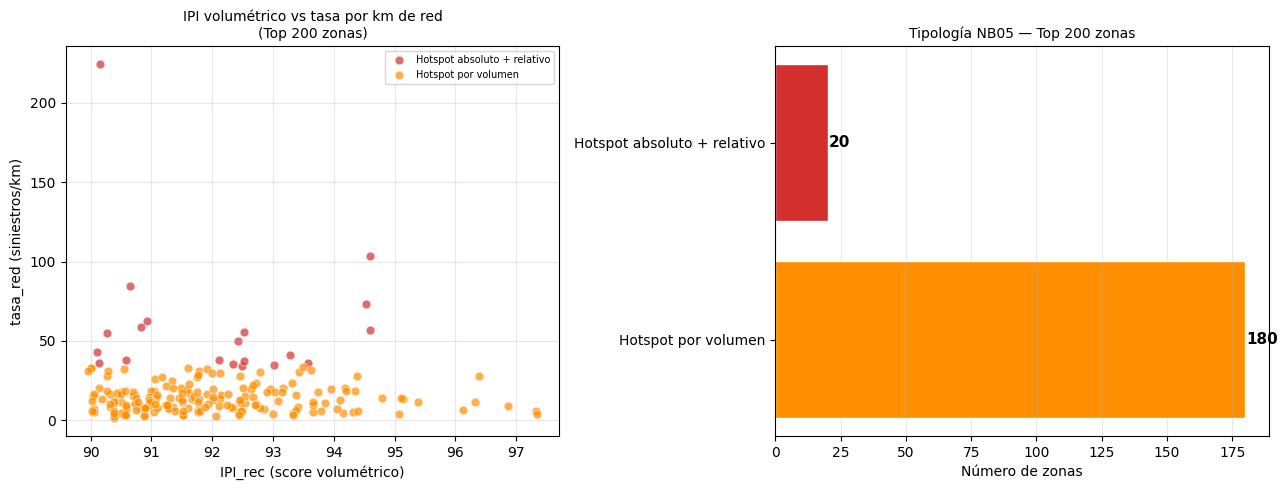

Figura guardada: C:\Users\jorge\Documents\viasegura_ai\outputs\reports\tipologia_nb05_comparativa.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: IPI_rec vs tasa_red con color por tipología
ax1 = axes[0]
df_top_plot = df[df["en_top200_rec"] == True].copy()
for tip, color in COLORES_TIP.items():
    sub = df_top_plot[df_top_plot["tipologia_nb05"] == tip]
    if len(sub) > 0:
        ax1.scatter(sub["IPI_rec"], sub["tasa_red"],
                   alpha=0.7, color=color, label=tip, s=40, edgecolors="white", linewidths=0.5)
ax1.set_xlabel("IPI_rec (score volumétrico)")
ax1.set_ylabel("tasa_red (siniestros/km)")
ax1.set_title("IPI volumétrico vs tasa por km de red\n(Top 200 zonas)", fontsize=10)
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

# Panel derecho: distribución de tipología en barras
ax2 = axes[1]
tip_data = df_top_plot["tipologia_nb05"].value_counts()
colors_bar = [COLORES_TIP.get(t, "#999") for t in tip_data.index]
bars = ax2.barh(tip_data.index, tip_data.values, color=colors_bar, edgecolor="white")
for b, v in zip(bars, tip_data.values):
    ax2.text(b.get_width()+0.5, b.get_y()+b.get_height()/2, str(v),
             va="center", fontsize=11, fontweight="bold")
ax2.set_xlabel("Número de zonas")
ax2.set_title("Tipología NB05 — Top 200 zonas", fontsize=10)
ax2.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
PATH_FIG = REPORTS / "tipologia_nb05_comparativa.png"
plt.savefig(PATH_FIG, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {PATH_FIG}")